<div style="padding:28px 32px;border:1px solid #d0d7de;border-radius:14px;">
  <div style="font-size:14px;letter-spacing:.08em;text-transform:uppercase;"><b>Complete Study Guide</b></div>
  <h1 style="margin:.35em 0 .15em 0;">Every Theory Behind the Pairs Trading Project</h1>
  <p style="font-size:18px;margin:.2em 0 0 0;">
    Statistical arbitrage, time-series tests, hedge ratios, spread trading, two-leg accounting, research design, and Alpaca paper execution.
  </p>
</div>

<br>

This notebook explains the **finished pairs-trading project**, including the exact financial and statistical ideas implemented in its Python files.

The project:

- Screens a stock universe
- Measures return correlation
- Tests price relationships for cointegration
- Estimates a regression hedge ratio
- Constructs a residual spread
- Tests spread stationarity
- Estimates mean-reversion half-life
- Converts spread divergence into z-score signals
- Trades long and short spreads
- Models two-leg weights, costs, short borrow, and compounding
- Selects parameters on training data
- Evaluates them out of sample
- Connects to Alpaca paper trading through a dry-run-first adapter

> **Educational warning:** Statistical arbitrage is not risk-free. Correlations and cointegration relationships can break suddenly and permanently.

## How to use this notebook

Read it once from top to bottom. Then use the formula sheet, glossary, code map, and questions for revision.

Code cells are either:

1. Small synthetic demonstrations
2. Exact or near-exact excerpts from the project
3. Auditing exercises that let you inspect the mechanics row by row

The notebook does not require market-data internet access.

## Contents

### Part I — What pairs trading is
1. Statistical arbitrage  
2. Relative value versus directional trading  
3. The project architecture  
4. The complete information flow  

### Part II — Market data and candidate pairs
5. Tickers, adjusted prices, and daily bars  
6. Time-series alignment and missing data  
7. Returns and log returns  
8. Correlation  
9. Why correlation is not enough  
10. Candidate-universe risk  

### Part III — The long-run relationship
11. Regression and the hedge ratio  
12. Why scikit-learn is used  
13. Intercept, beta, and residual spread  
14. Price levels versus log prices  
15. R-squared  
16. Cointegration  
17. Engle–Granger test  
18. ADF test  
19. Stationarity  
20. Mean-reversion half-life  
21. Pair ranking and eligibility  

### Part IV — Trading the spread
22. Rolling mean and standard deviation  
23. Z-scores  
24. Long-spread trade  
25. Short-spread trade  
26. Stateful signals  
27. Entry threshold  
28. Exit threshold  
29. Stop threshold  
30. Maximum holding period  
31. Whipsaw and hysteresis  
32. Fixed versus rolling hedge ratios  

### Part V — Two-leg portfolio accounting
33. Target versus executed spread position  
34. Look-ahead bias  
35. Gross-normalized leg weights  
36. Gross and net exposure  
37. Two-leg returns  
38. Turnover  
39. Transaction costs  
40. Short-borrow cost  
41. Cash return  
42. Net strategy return  
43. Compounding  
44. Drawdown  
45. Pair trade extraction  
46. Reversals and leg risk  

### Part VI — Performance statistics
47. Total return  
48. Annualized return  
49. Volatility  
50. Risk-free rate  
51. Sharpe ratio  
52. Sortino ratio  
53. Maximum drawdown  
54. Daily win rate  
55. Market exposure  
56. Turnover and order counts  
57. Trade win rate  
58. Profit factor  
59. Holding period  
60. Passive benchmark  

### Part VII — Research design
61. Training and testing data  
62. Pair selection on training data  
63. Parameter grids  
64. Selection objective  
65. Minimum-trade filters  
66. Indicator warm-up  
67. Fresh-start test boundary  
68. Full-period results  
69. Overfitting  
70. Multiple testing  
71. Structural breaks  
72. P-values and uncertainty  

### Part VIII — Alpaca paper trading
73. Research versus execution  
74. API credentials  
75. Historical bars  
76. Account equity and target notional  
77. Integer-share conversion  
78. Current-position reconciliation  
79. Shortability checks  
80. Market orders  
81. Client order IDs  
82. Dry-run safety  
83. Non-atomic pair orders  
84. Paper versus live fills  

### Part IX — Engineering and limitations
85. Caching  
86. CSV and JSON exports  
87. Charts  
88. Unit tests  
89. Defensive validation  
90. Complete limitations  
91. Professional extensions  

### Revision
92. Complete code-to-theory map  
93. Formula sheet  
94. Glossary  
95. Revision questions  
96. Answers

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

print("Notebook setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-4lgftyw_ because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Notebook setup complete.


# Part I — What pairs trading is

---

# 1. Statistical arbitrage

**Statistical arbitrage** uses statistical relationships to form trading rules.

Pairs trading does not simply ask:

> Will this stock rise?

It asks:

> Has the relationship between two historically connected stocks moved unusually far from its estimated equilibrium?

The strategy attempts to profit if the relationship converges.

<div style="padding:14px 18px;border-left:5px solid #d29922;background:transparent;">
<b>Core idea</b><br>
Trade the relative mispricing between two assets rather than taking a pure market-direction view.
</div>

# 2. Relative value versus directional trading

## Directional strategy

A long-only momentum strategy gains mainly when the market rises.

## Relative-value strategy

A pairs trade owns one leg and shorts the other.

Common market moves can partially offset:

```text
Long Y return + Short X return
```

The intended source of profit is spread convergence, not simply a rising stock market.

This does not guarantee market neutrality. The hedge can be imperfect.

# 3. The project architecture

| File | Responsibility |
|---|---|
| `pair_data.py` | Downloads, caches, cleans, and aligns prices |
| `pair_selection.py` | Correlation, OLS hedge ratio, cointegration, ADF, and half-life |
| `pair_strategy.py` | Spread z-score signal state machine |
| `pair_backtester.py` | Two-leg weights, P&L, costs, borrow, trades, and metrics |
| `research.py` | Pair selection, grid search, period runs, and summaries |
| `main.py` | Complete research workflow and charts |
| `alpaca_paper.py` | Dry-run-first paper-trading adapter |
| `tests/` | Deterministic synthetic validation |

# 4. The complete information flow

```text
Adjusted prices for a stock universe
                ↓
Aligned daily returns
                ↓
Return-correlation filter
                ↓
OLS hedge ratio
                ↓
Residual spread
                ↓
Cointegration + ADF + half-life
                ↓
Selected training-period pair
                ↓
Rolling spread z-score
                ↓
Long / flat / short spread signal
                ↓
One-day execution delay
                ↓
Hedge-ratio leg weights
                ↓
Two-leg return - costs - borrow
                ↓
Portfolio, trades, and risk metrics
                ↓
Out-of-sample evaluation
                ↓
Optional Alpaca paper orders
```

# Part II — Market data and candidate pairs

---

# 5. Tickers, adjusted prices, and daily bars

A ticker identifies a security, such as `KO` or `PEP`.

The research downloader uses adjusted daily closing prices.

Adjusted data attempts to account for corporate actions such as:

- Splits
- Dividends
- Other provider-supported adjustments

A split should not appear as a genuine 50% economic loss.

## Daily-bar abstraction

The project observes one adjusted closing price per trading day.

It ignores:

- Intraday path
- Bid and ask
- Opening price
- Exact execution time
- Intraday stop events
- Partial fills

The model is therefore a daily close-to-close research engine.

# 6. Time-series alignment and missing data

Two stocks must be compared on the same dates.

Exact project idea:

```python
pair = prices[[symbol_y, symbol_x]].dropna()
```

If one stock is missing a date, that row is removed from both legs.

Otherwise, the regression could compare prices from different days.

In [2]:
dates = pd.date_range("2025-01-01", periods=5)
y = pd.Series([100, 101, np.nan, 103, 104], index=dates, name="Y")
x = pd.Series([50, 50.5, 51, 51.5, 52], index=dates, name="X")

aligned = pd.concat([y, x], axis=1).dropna()
aligned

,Y,X
2025-01-01,100.000000,50.000000
2025-01-02,101.000000,50.500000
2025-01-04,103.000000,51.500000
2025-01-05,104.000000,52.000000


## Coverage filter

The downloader removes symbols that fail a minimum fraction of available observations.

This avoids screening pairs where one stock has very little usable history.

Coverage is a data-quality rule, not a trading signal.

# 7. Returns and log returns

Simple return:

$$
r_t=\frac{P_t}{P_{t-1}}-1
$$

Log return:

$$
g_t=\ln(P_t)-\ln(P_{t-1})
=\ln\left(\frac{P_t}{P_{t-1}}\right)
$$

The project uses log-return correlation during pair screening.

For small moves, simple and log returns are numerically similar.

In [3]:
prices = pd.Series([100, 102, 99, 103], name="price")

simple_return = prices.pct_change()
log_return = np.log(prices).diff()

pd.DataFrame({
    "price": prices,
    "simple_return": simple_return,
    "log_return": log_return,
})

,price,simple_return,log_return
0,100,NaN,NaN
1,102,0.020000,0.019803
2,99,-0.029412,-0.029853
3,103,0.040404,0.039609


## Why log prices and log returns are useful

Log prices turn multiplicative price ratios into additive differences.

A relationship such as:

```text
Y is proportional to X^beta
```

becomes linear:

```text
log(Y) = alpha + beta × log(X)
```

This is convenient for regression and spread construction.

# 8. Correlation

Pearson correlation measures linear co-movement.

For returns:

$$

ho_{XY}=
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X\sigma_Y}
$$

Range:

| Correlation | Interpretation |
|---:|---|
| +1 | Perfect positive linear movement |
| 0 | No linear relationship |
| -1 | Perfect negative linear movement |

In [4]:
rng = np.random.default_rng(4)
x_returns = pd.Series(rng.normal(0, 0.01, 500))
y_returns = 0.8 * x_returns + pd.Series(rng.normal(0, 0.006, 500))

x_returns.corr(y_returns)

np.float64(0.7792481480414087)

# 9. Why correlation is not enough

Two prices can have highly correlated returns while their price relationship drifts without bound.

Correlation answers:

> Do short-term changes move together?

Cointegration asks:

> Does a particular long-run combination remain mean-reverting?

Pairs trading needs more than visually similar charts.

In [5]:
rng = np.random.default_rng(10)
n = 700

common = np.cumsum(rng.normal(0, 1, n))
independent_drift = np.cumsum(rng.normal(0, 0.25, n))

price_a = 100 + common
price_b = 100 + common + independent_drift

returns = pd.DataFrame({"A": price_a, "B": price_b}).pct_change().dropna()
spread = pd.Series(price_a - price_b)

print("Return correlation:", returns.corr().iloc[0, 1])
print("Spread start/end:", spread.iloc[0], spread.iloc[-1])

Return correlation: 0.9647542824468198
Spread start/end: 0.13653782478796472 7.863011398557845


# 10. Candidate-universe risk

The project screens every pair in a predefined universe.

The universe itself introduces selection assumptions.

Possible biases:

- Only current successful companies are included
- Delisted firms are absent
- Sector composition is chosen after seeing history
- Similar business models may change
- Corporate events may break comparability

A pair finder cannot discover relationships outside the symbols it was given.

# Part III — The long-run relationship

---

# 11. Regression and the hedge ratio

The project fits:

$$
Y_t=\alpha+\beta X_t+\varepsilon_t
$$

With log prices:

$$
\ln(Y_t)=\alpha+\beta\ln(X_t)+\varepsilon_t
$$

The residual $\varepsilon_t$ becomes the spread.

## Hedge ratio

`beta` estimates how much X is associated with one unit of Y in the fitted relationship.

Example:

```text
beta = 1.4
```

The spread is:

```text
Y - alpha - 1.4 × X
```

The trading portfolio uses a beta-adjusted X leg.

# 12. Why scikit-learn is used

Exact project method:

```python
model = LinearRegression(fit_intercept=True)
model.fit(x, y)
```

`LinearRegression` solves ordinary least squares.

It chooses coefficients that minimize:

$$
\sum_t
\left(Y_t-\alpha-\beta X_t
ight)^2
$$

In [6]:
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(5)
x = np.linspace(1, 10, 100)
y = 2.0 + 1.5 * x + rng.normal(0, 0.4, 100)

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

print("Estimated alpha:", model.intercept_)
print("Estimated beta:", model.coef_[0])
print("R-squared:", model.score(x.reshape(-1, 1), y))

Estimated alpha: 1.9278191611102553
Estimated beta: 1.4968323512956145
R-squared: 0.9919894157639081


# 13. Intercept, beta, and residual spread

The project constructs:

```python
spread = y - alpha - beta * x
```

The spread is not merely `Y - X`.

The intercept and hedge ratio remove the fitted long-run relationship.

In [7]:
alpha = model.intercept_
beta = model.coef_[0]
residual = y - alpha - beta * x

pd.Series(residual).describe()

count   100.000000
mean      0.000000
std       0.354755
min      -0.711684
25%      -0.305598
50%      -0.021494
75%       0.218086
max       1.064744
dtype: float64

## Regression direction matters

Regressing Y on X is not identical to regressing X on Y.

Ordinary least squares minimizes vertical Y residuals.

Therefore:

- The beta changes if the dependent variable changes
- The residual spread changes
- Cointegration p-values can differ slightly

The project fixes one direction for reproducibility.

# 14. Price levels versus log prices

The project defaults to log prices.

## Level regression

$$
Y=\alpha+\beta X+\varepsilon
$$

## Log regression

$$
\ln(Y)=\alpha+\beta\ln(X)+\varepsilon
$$

Log regression often makes proportional relationships easier to model.

It also requires positive prices.

# 15. R-squared

R-squared measures how much in-sample variation in Y is explained by fitted X.

$$
R^2=1-\frac{SS_{residual}}{SS_{total}}
$$

A high R-squared does **not** prove cointegration.

Two unrelated trending series can produce a high R-squared. This is called spurious regression.

# 16. Cointegration

Two non-stationary series are cointegrated if a linear combination of them is stationary.

Informally:

```text
Each price may wander,
but the fitted spread does not wander without limit.
```

Cointegration is the central statistical idea behind classic pairs trading.

# 17. Engle–Granger test

The project calls `statsmodels.tsa.stattools.coint`.

Null hypothesis:

> The two series are not cointegrated.

A small p-value provides evidence against that null.

Example rule:

```text
cointegration p-value ≤ 0.05
```

This is evidence, not certainty.

## What the test does conceptually

1. Regress one price series on the other
2. Examine the residual
3. Test whether the residual behaves like a stationary process

The critical values are not the same as an ordinary regression t-test.

# 18. ADF test

The project also runs the Augmented Dickey–Fuller test directly on the fitted spread.

Null hypothesis:

> The spread has a unit root and is non-stationary.

A small p-value supports rejecting the unit-root null.

## Why use both cointegration and ADF?

They are related, but reporting both makes the diagnostics transparent.

- Cointegration test evaluates the pair relationship
- ADF directly examines the chosen residual spread

Neither guarantees future stationarity.

# 19. Stationarity

A weakly stationary series has stable properties such as:

- Constant mean
- Constant variance
- Autocovariance depending on lag rather than date

Pairs trading relies on an approximate assumption that spread deviations are temporary.

Real financial spreads can change regimes and violate stationarity.

# 20. Mean-reversion half-life

The project estimates:

$$
\Delta S_t=a+bS_{t-1}+\eta_t
$$

If $b<0$, deviations tend to shrink.

Approximate half-life:

$$
h=-\frac{\ln 2}{b}
$$

Half-life estimates how many periods it takes a deviation to decay by half.

In [8]:
rng = np.random.default_rng(12)
spread = [0.0]
for _ in range(600):
    spread.append(0.90 * spread[-1] + rng.normal(0, 0.02))

spread = pd.Series(spread)
lagged = spread.shift(1)
delta = spread.diff()
regression = pd.concat([delta.rename("delta"), lagged.rename("lagged")], axis=1).dropna()

hl_model = LinearRegression().fit(regression[["lagged"]], regression["delta"])
speed = hl_model.coef_[0]
half_life = -math.log(2) / speed

speed, half_life

(np.float64(-0.11465542695890009), np.float64(6.045480784859961))

## Half-life interpretation

Very short half-life:

- Fast convergence
- Potentially frequent trading
- Costs may dominate

Very long half-life:

- Capital remains tied up
- Relationship may be too slow
- Structural-break risk increases

The project keeps candidates inside a configured range.

# 21. Pair ranking and eligibility

A pair must satisfy configured rules for:

- Minimum observations
- Minimum absolute return correlation
- Maximum cointegration p-value
- Maximum ADF p-value
- Minimum half-life
- Maximum half-life

Eligible pairs are ranked using stationarity evidence and correlation.

If no pair passes every rule, the project can display the strongest fallback with a warning.

<div style="padding:14px 18px;border-left:5px solid #cf222e;background:transparent;">
<b>Important</b><br>
A fallback pair is useful for education, but failing strict diagnostics is not permission to claim a valid statistical-arbitrage relationship.
</div>

# Part IV — Trading the spread

---

# 22. Rolling mean and standard deviation

The strategy calculates a rolling spread mean:

$$
\mu_t=\frac{1}{L}\sum_{i=0}^{L-1}S_{t-i}
$$

and rolling population standard deviation:

$$
\sigma_t=
\sqrt{\frac{1}{L}\sum_{i=0}^{L-1}(S_{t-i}-\mu_t)^2}
$$

The project uses `ddof=0` inside the rolling window.

# 23. Z-scores

$$
z_t=\frac{S_t-\mu_t}{\sigma_t}
$$

Interpretation:

- `z = 0`: spread equals its rolling mean
- `z = +2`: spread is two rolling standard deviations above the mean
- `z = -2`: spread is two rolling standard deviations below the mean

In [9]:
spread_demo = pd.Series([0.00, 0.01, -0.01, 0.00, 0.02, -0.08, -0.10, -0.02, 0.00])
lookback = 4

mean_demo = spread_demo.rolling(lookback).mean()
std_demo = spread_demo.rolling(lookback).std(ddof=0)
z_demo = (spread_demo - mean_demo) / std_demo.replace(0, np.nan)

pd.DataFrame({
    "spread": spread_demo,
    "rolling_mean": mean_demo,
    "rolling_std": std_demo,
    "zscore": z_demo,
})

,spread,rolling_mean,rolling_std,zscore
0,0.000000,NaN,NaN,NaN
1,0.010000,NaN,NaN,NaN
2,-0.010000,NaN,NaN,NaN
3,0.000000,0.000000,0.007071,0.000000
4,0.020000,0.005000,0.011180,1.341641
5,-0.080000,-0.017500,0.037666,-1.659308
6,-0.100000,-0.040000,0.050990,-1.176697
7,-0.020000,-0.045000,0.047697,0.524142
8,0.000000,-0.050000,0.041231,1.212678


## A z-score is not a probability guarantee

A z-score is a standardized distance.

The project does not require the spread to be normally distributed.

Statements such as “a 2-sigma event happens only 5% of the time” require distributional assumptions that may not hold.

# 24. Long-spread trade

When the spread is unusually low:

```text
z-score ≤ -entry threshold
```

the strategy enters a long spread:

```text
Long Y
Short beta-adjusted X
```

It profits if the spread rises.

# 25. Short-spread trade

When the spread is unusually high:

```text
z-score ≥ entry threshold
```

the strategy enters a short spread:

```text
Short Y
Long beta-adjusted X
```

It profits if the spread falls.

# 26. Stateful signals

The strategy remembers whether it is:

- Flat
- Long spread
- Short spread

The same z-score can produce different actions depending on the current state.

This is a state machine, not a one-line independent classification.

# 27. Entry threshold

Larger entry threshold:

- Fewer trades
- More extreme divergence
- Possibly stronger signal
- Less sample size
- More risk that the relationship is breaking

Smaller threshold:

- More trades
- More transaction costs
- More noise and whipsaw

# 28. Exit threshold

Long spread exits when:

$$
z \ge -z_{exit}
$$

Short spread exits when:

$$
z \le z_{exit}
$$

With exit threshold `0.25`, the trade can close before reaching exactly zero.

# 29. Stop threshold

A long spread entered at negative z is stopped if z becomes even more negative beyond the stop.

A short spread entered at positive z is stopped if z becomes even more positive.

The stop acknowledges:

> Divergence may represent structural change rather than temporary mispricing.

# 30. Maximum holding period

The strategy exits after a configured number of signal days.

Reasons:

- Relationship may not converge
- Capital can remain trapped
- Old signals can lose relevance
- Half-life estimates are uncertain

A time exit is a risk-management rule, not proof the trade is wrong.

# 31. Whipsaw and hysteresis

Separate entry and exit thresholds create hysteresis.

Example:

```text
Enter at |z| ≥ 2
Exit near |z| ≤ 0.25
```

The strategy does not reverse every time z moves around 2 or 0.

Hysteresis reduces rapid switching, though it does not eliminate it.

# 32. Fixed versus rolling hedge ratios

The project estimates alpha and beta on training data and freezes them.

Advantages:

- Clear out-of-sample test
- No hidden future refitting
- Easier interpretation

Weaknesses:

- The relationship may evolve
- Fixed beta may become stale

Professional extensions include:

- Rolling OLS
- Kalman filters
- State-space models
- Time-varying cointegration

# Part V — Two-leg portfolio accounting

---

# 33. Target versus executed spread position

`target_position` is the strategy decision.

`spread_position` is the delayed position used for returns.

Values:

| Position | Meaning |
|---:|---|
| 1 | Long spread |
| 0 | Flat |
| -1 | Short spread |

# 34. Look-ahead bias

Exact idea:

```python
spread_position = target.shift(execution_delay)
```

With a one-day delay, a signal calculated from today's close cannot earn today's close-to-close return.

Without the delay, the strategy would use information from the end of the interval to choose the position for that same interval.

# 35. Gross-normalized leg weights

The project calculates:

$$
w_Y=\frac{p}{1+|\beta|}
$$

$$
w_X=\frac{-p\beta}{1+|\beta|}
$$

where $p\in\{-1,0,1\}$ is spread direction.

Therefore:

$$
|w_Y|+|w_X|=1
$$

during an active trade.

In [10]:
positions = pd.Series([1.0, -1.0, 0.0], name="spread_position")
beta = 1.5

weight_y = positions / (1 + abs(beta))
weight_x = -positions * beta / (1 + abs(beta))

weights = pd.DataFrame({"weight_y": weight_y, "weight_x": weight_x})
weights["gross_exposure"] = weights.abs().sum(axis=1)
weights["net_exposure"] = weights.sum(axis=1)
weights

,weight_y,weight_x,gross_exposure,net_exposure
0,0.400000,-0.600000,1.000000,0.800000
1,-0.400000,0.600000,1.000000,1.200000
2,0.000000,-0.000000,0.000000,0.000000


## Gross normalized is not always dollar neutral

If beta is not 1:

$$
w_Y+w_X 
e 0
$$

The portfolio can have non-zero net dollar exposure.

It is hedge-ratio weighted and gross-normalized, not guaranteed perfectly dollar-neutral or beta-neutral.

# 36. Gross and net exposure

Gross exposure:

$$
|w_Y|+|w_X|
$$

Net exposure:

$$
w_Y+w_X
$$

Gross measures total capital at risk on both legs.

Net measures directional dollar imbalance.

# 37. Two-leg returns

The gross pair return is:

$$
r_{pair,t}=w_{Y,t}r_{Y,t}+w_{X,t}r_{X,t}
$$

A long-spread trade gains when Y outperforms the beta-adjusted X leg.

In [11]:
r_y = pd.Series([0.02, -0.01, 0.03])
r_x = pd.Series([0.01, 0.00, 0.04])
w_y = pd.Series([0.4, 0.4, -0.4])
w_x = pd.Series([-0.6, -0.6, 0.6])

gross_pair_return = w_y * r_y + w_x * r_x

pd.DataFrame({
    "return_y": r_y,
    "return_x": r_x,
    "weight_y": w_y,
    "weight_x": w_x,
    "gross_pair_return": gross_pair_return,
})

,return_y,return_x,weight_y,weight_x,gross_pair_return
0,0.020000,0.010000,0.400000,-0.600000,0.002000
1,-0.010000,0.000000,0.400000,-0.600000,-0.004000
2,0.030000,0.040000,-0.400000,0.600000,0.012000


# 38. Turnover

Each leg has separate turnover:

$$
TO_Y=|w_{Y,t}-w_{Y,t-1}|
$$

$$
TO_X=|w_{X,t}-w_{X,t-1}|
$$

Total:

$$
TO=TO_Y+TO_X
$$

A pair entry usually trades both legs.

# 39. Transaction costs

$$
Cost_t=TO_t\times c
$$

The constant rate is a proxy for:

- Bid-ask spread
- Commission
- Fees
- Slippage
- Market impact

Real costs differ by symbol, size, volatility, and time.

# 40. Short-borrow cost

One leg is usually short.

The project estimates daily borrow rate:

$$
b_d=(1+b_a)^{1/252}-1
$$

Then:

$$
BorrowCost_t=ShortNotional_t\times b_d
$$

Borrow costs are uncertain and can spike.

## Missing short risks

The backtest does not model:

- Locate availability
- Hard-to-borrow fees
- Recalls
- Buy-ins
- Margin changes
- Short squeezes
- Dividend payments owed by short sellers

# 41. Cash return

When gross exposure is zero, the engine can credit the configured daily risk-free return.

While a pair is active, the simplified model does not separately credit collateral or short-sale proceeds.

Real broker cash and margin accounting is more complex.

# 42. Net strategy return

$$
r_{net}
=
r_{pair}
+r_{cash}
-Cost
-BorrowCost
$$

This is the return compounded into the portfolio.

# 43. Compounding

$$
V_t=V_0\prod_{i=1}^{t}(1+r_{net,i})
$$

Losses and gains apply to the latest wealth level.

Returns should not simply be added across a long period.

# 44. Drawdown

$$
DD_t=\frac{V_t}{\max(V_1,\ldots,V_t)}-1
$$

Maximum drawdown is the most negative drawdown.

It captures historical peak-to-trough pain.

# 45. Pair trade extraction

A completed pair trade records:

- Entry and exit dates
- Long-spread or short-spread side
- Entry and exit price of both legs
- Entry and exit z-score
- Holding days
- Compounded net trade return
- Open or closed status

Entry and exit costs are included in trade return.

# 46. Reversals and leg risk

A direct switch from long spread to short spread closes one pair and opens the opposite pair.

In real execution, four economic actions may be required:

- Sell or cover Y
- Sell or cover X
- Open new Y side
- Open new X side

Separate orders can fill at different prices and times.

This is **leg risk**.

# Part VI — Performance statistics

---

# 47. Total return

$$
R_{total}=\frac{V_T}{V_0}-1
$$

It measures full-period compounded gain or loss.

# 48. Annualized return

$$
R_{annual}=
\left(\frac{V_T}{V_0}
\right)^{1/T}-1
$$

This is compound annual growth rate over elapsed calendar years.

# 49. Volatility

Daily standard deviation:

$$
\sigma_d=Std(r_t)
$$

Annualized:

$$
\sigma_a=\sigma_d\sqrt{252}
$$

Square-root scaling assumes stable, approximately independent variance.

# 50. Risk-free rate

Annual risk-free return is converted to a daily compound-equivalent rate:

$$
r_{f,d}=(1+r_{f,a})^{1/252}-1
$$

It is used for excess-return metrics and flat cash return.

# 51. Sharpe ratio

$$
Sharpe=
\frac{\overline{r-r_f}}
{\sigma(r)}
\sqrt{252}
$$

Higher Sharpe means more average excess return per unit of total volatility.

It is the parameter-search objective in the project.

# 52. Sortino ratio

The project divides mean excess return by downside-return standard deviation.

It penalizes negative observations rather than all variation.

Multiple Sortino definitions exist, so metric methodology must be documented.

# 53. Maximum drawdown

Maximum drawdown reports the worst historical decline from a previous portfolio high.

It does not show:

- Drawdown duration
- Recovery time
- Frequency
- Whether recovery occurred

# 54. Daily win rate

The fraction of active-position days with positive net strategy return.

This is not the same as trade win rate.

A multi-day trade contains many daily outcomes.

# 55. Market exposure

The project reports the fraction of observations with non-zero spread position.

A strategy can have low volatility partly because it spends substantial time flat.

# 56. Turnover and order counts

Metrics include:

- Total turnover
- Rebalance days
- Leg orders

One pair entry can create two leg orders.

Order count is not identical to trade count.

# 57. Trade win rate

$$
WinRate=
\frac{\text{profitable closed pair trades}}
{\text{all closed pair trades}}
$$

A low win rate can still be profitable if winners are much larger than losers.

# 58. Profit factor

$$
PF=
\frac{\sum positive\ trade\ returns}
{|\sum negative\ trade\ returns|}
$$

Above 1 means winning-return magnitude exceeds losing-return magnitude.

The project sums percentage trade returns, not cash P&L.

# 59. Holding period

Average holding days shows how long capital remains in a pair trade.

Long holding times can increase:

- Borrow cost
- Structural-break exposure
- Opportunity cost

# 60. Passive benchmark

The project compares with a 50/50 initial allocation to the two stocks.

It buys both legs long and does not rebalance.

This benchmark is directional and not market-neutral, but it answers:

> Was the complex pair strategy better than simply owning both selected companies?

# Part VII — Research design

---

# 61. Training and testing data

Training data is used for:

- Pair screening
- Hedge-ratio estimation
- Strategy parameter selection

Testing data is used after those choices are frozen.

Testing is the main out-of-sample evidence.

# 62. Pair selection on training data

Selecting the pair using all history would leak testing information.

The project estimates:

- Correlation
- Cointegration
- ADF
- Alpha
- Beta
- Half-life

using training dates only.

# 63. Parameter grids

The project tries combinations of:

- Z-score lookback
- Entry threshold
- Exit threshold
- Stop threshold
- Maximum holding period

Every tested combination is recorded in a CSV.

# 64. Selection objective

Results are sorted by:

1. Training Sharpe ratio
2. Training annualized return
3. Maximum drawdown as an additional tie preference

The objective defines what “best” means.

# 65. Minimum-trade filters

A candidate strategy should have enough completed trades to make metrics less fragile.

If no configuration reaches the minimum, the project falls back to available results.

Even five trades are not statistically strong evidence.

# 66. Indicator warm-up

Testing z-scores need earlier spread observations.

The project computes signals using full historical prices, then aligns them to the testing dates.

Past observations are valid warm-up data.

# 67. Fresh-start test boundary

The testing backtest starts with:

- Fresh capital
- Cash
- No carried open training trade

Indicators are warmed up, but the executed position is re-shifted inside the testing slice.

This is a fresh-start out-of-sample test, not one continuous portfolio.

# 68. Full-period results

Full-period results use the selected training pair and parameters across all dates.

They are descriptive because the period includes data used for selection.

The testing period is more independent.

# 69. Overfitting

Overfitting occurs when historical noise is mistaken for a durable relationship.

Signs include:

- Excellent training Sharpe
- Poor testing results
- One exact parameter set works
- Nearby values fail
- Very few trades
- Complex rules

# 70. Multiple testing

Screening many pairs and many parameter combinations increases the chance of finding an apparently strong result by luck.

This is data snooping.

The reported best p-value and best Sharpe are selected extrema, not unbiased estimates.

# 71. Structural breaks

Cointegration can disappear because of:

- Acquisition
- Spin-off
- Business-model change
- Leverage change
- Commodity exposure change
- Regulation
- Index membership
- Crisis
- Accounting event

A stationary historical spread can become non-stationary.

# 72. P-values and uncertainty

A p-value is not:

- Probability the pair is truly cointegrated
- Probability the trade will win
- Guarantee the relationship continues

It is evidence under a statistical model and null hypothesis.

Assumptions and multiple testing matter.

# Part VIII — Alpaca paper trading

---

# 73. Research versus execution

A research signal is not an order.

Execution requires:

- Current account state
- Current prices
- Quantity rounding
- Tradability
- Shortability
- Order type
- Fill monitoring
- Failure handling

# 74. API credentials

The paper adapter reads:

```text
ALPACA_API_KEY
ALPACA_SECRET_KEY
```

Credentials should be stored in environment variables or `.env`, not committed to source control.

# 75. Historical bars

The adapter uses Alpaca's stock historical-data client and requests daily bars for both symbols.

It requests enough calendar history to warm the rolling z-score.

The signal is calculated from completed daily bars.

# 76. Account equity and target notional

The adapter reads paper-account equity.

$$
GrossDollars=
Equity\times AllocationFraction
$$

A default 20% allocation leaves the rest outside the pair strategy.

# 77. Integer-share conversion

Target dollars are converted to shares:

$$
Shares = round\left(\frac{TargetDollars \times Weight}{Price}\right)
$$

Integer rounding changes the exact hedge.

Small accounts can produce zero shares in one leg.

# 78. Current-position reconciliation

The adapter reads current positions and calculates:

$$
DeltaShares=
TargetShares-CurrentShares
$$

Orders trade only the difference.

This is rebalancing, not blindly sending the full target every run.

# 79. Shortability checks

Before proposing a negative target quantity, the adapter checks that Alpaca marks the asset shortable.

Shortability can change between checks and order submission.

# 80. Market orders

A market order prioritizes execution over exact price.

It can experience slippage.

The project uses market orders only in the paper adapter for simplicity.

# 81. Client order IDs

Each order receives a unique strategy-specific client order ID.

Benefits:

- Tracking
- Debugging
- Distinguishing strategy orders
- Avoiding accidental duplicates in more advanced systems

# 82. Dry-run safety

Running:

```bash
python alpaca_paper.py
```

prints a plan and submits nothing.

Actual paper submission requires:

```bash
python alpaca_paper.py --execute-paper
```

The trading client is explicitly constructed with `paper=True`.

# 83. Non-atomic pair orders

The two legs are separate stock orders.

Possible sequence:

1. First leg fills
2. Market moves
3. Second leg fills later or fails

During the gap, the account has unintended directional exposure.

Production systems need order-state monitoring and leg-risk controls.

# 84. Paper versus live fills

Paper trading may not reproduce:

- Queue priority
- Real spread
- Market impact
- Borrow constraints
- Partial fills
- Rejections
- Latency

Paper success is operational practice, not live-performance proof.

# Part IX — Engineering and limitations

---

# 85. Caching

Historical downloads are cached using a hash of:

- Symbols
- Start date
- End date

Caching improves repeatability and speed.

Refreshing can update provider revisions.

# 86. CSV and JSON exports

The workflow exports:

- Pair rankings
- Parameter search
- Selected pair and model parameters
- Daily results
- Signals
- Trades
- Summary metrics

These files make the research auditable.

# 87. Charts

The project creates:

- Normalized pair prices
- Regression spread
- Z-score thresholds
- Out-of-sample portfolio
- Drawdown
- Executed leg weights

Each chart answers a different question.

# 88. Unit tests

Synthetic tests validate:

- Hedge-ratio recovery
- Spread residual formula
- Cointegration diagnostics
- Signal entry
- Long and short spread states
- Execution delay
- Weight normalization
- Two-leg costs
- Borrow costs
- Input rejection

# 89. Defensive validation

The code rejects:

- Too few symbols
- Non-positive prices
- Invalid z-score thresholds
- Invalid position values
- Invalid cost rates
- Invalid holding periods
- Missing pair columns
- Insufficient observations

Validation prevents plausible-looking nonsense.

# 90. Complete limitations

1. Daily close-only data  
2. No intraday execution  
3. Fixed training hedge ratio  
4. Constant transaction cost  
5. Constant borrow rate  
6. No dividend liability on shorts as a separate cash flow  
7. No hard-to-borrow dynamics  
8. No market impact  
9. No liquidity limits  
10. No margin calls  
11. No taxes  
12. No atomic pair orders  
13. Integer rounding in paper trading  
14. No portfolio of multiple pairs  
15. No factor-neutralization  
16. Net exposure may not be zero  
17. Cointegration tests face multiple-testing bias  
18. P-values rely on model assumptions  
19. Rolling z-score may adapt after a structural break  
20. Fresh-start test does not carry an open position  
21. Candidate universe may have survivorship bias  
22. Adjusted-price quality depends on provider  
23. Passive benchmark is directional  
24. Paper fills are optimistic  
25. Historical success does not imply future success

# 91. Professional extensions

- Sector and industry clustering
- PCA pair discovery
- False-discovery-rate control
- Johansen multivariate cointegration
- Rolling or Kalman-filter hedge ratios
- Structural-break tests
- Walk-forward pair reselection
- Multiple-pair portfolio
- Volatility targeting
- Factor and beta neutrality
- Dynamic borrow data
- Quote-based transaction costs
- Limit-order simulation
- Order monitoring
- Kill switches
- Leg-risk hedging
- Confidence intervals
- Bootstrap and Monte Carlo analysis

## Complete miniature synthetic example

The next cells use the real project modules when this notebook is in the project folder.

In [12]:
try:
    from pair_backtester import PairBacktestConfig, run_pair_backtest
    from pair_selection import (
        PairSelectionConfig,
        calculate_spread,
        evaluate_pair,
        fit_hedge_ratio,
    )
    from pair_strategy import PairStrategyConfig, build_pair_signal

    project_available = True
    print("Project modules imported successfully.")
except ImportError as exc:
    project_available = False
    print("Project modules were not found:", exc)

Project modules imported successfully.


In [13]:
if project_available:
    rng = np.random.default_rng(42)
    n = 900
    dates = pd.date_range("2018-01-01", periods=n, freq="B")

    log_x = np.log(100) + np.cumsum(rng.normal(0, 0.008, n))
    stationary_spread = np.zeros(n)
    for i in range(1, n):
        stationary_spread[i] = (
            0.88 * stationary_spread[i - 1]
            + rng.normal(0, 0.012)
        )

    true_alpha = 0.20
    true_beta = 0.95
    log_y = true_alpha + true_beta * log_x + stationary_spread

    synthetic_prices = pd.DataFrame(
        {
            "Y": np.exp(log_y),
            "X": np.exp(log_x),
        },
        index=dates,
    )

    synthetic_prices.head()
else:
    print("Skipped.")

In [14]:
if project_available:
    hedge = fit_hedge_ratio(
        synthetic_prices["Y"],
        synthetic_prices["X"],
        use_log_prices=True,
    )
    hedge
else:
    print("Skipped.")

In [15]:
if project_available:
    diagnostics = evaluate_pair(
        synthetic_prices,
        "Y",
        "X",
        PairSelectionConfig(
            minimum_observations=500,
            minimum_absolute_return_correlation=0.0,
            maximum_cointegration_pvalue=0.10,
            maximum_adf_pvalue=0.10,
            minimum_half_life=1.0,
            maximum_half_life=200.0,
            use_log_prices=True,
        ),
    )
    pd.Series(diagnostics)
else:
    print("Skipped.")

In [16]:
if project_available:
    strategy_config = PairStrategyConfig(
        zscore_lookback=40,
        entry_zscore=2.0,
        exit_zscore=0.25,
        stop_zscore=4.0,
        maximum_holding_days=60,
    )

    signal = build_pair_signal(
        synthetic_prices,
        "Y",
        "X",
        diagnostics["alpha"],
        diagnostics["beta"],
        strategy_config,
        use_log_prices=True,
    )

    signal.tail()
else:
    print("Skipped.")

In [17]:
if project_available:
    backtest_config = PairBacktestConfig(
        initial_capital=10_000,
        transaction_cost_rate=0.001,
        annual_borrow_rate=0.03,
        annual_risk_free_rate=0.0,
        execution_delay=1,
    )

    results, metrics, trades = run_pair_backtest(
        synthetic_prices,
        "Y",
        "X",
        signal["target_position"],
        diagnostics["beta"],
        backtest_config,
        signal_frame=signal,
    )

    display(pd.Series(metrics).to_frame("value"))
    display(trades.tail(10))
else:
    print("Skipped.")

,value
final_value,"13,598.110541"
total_return,0.359811
annualized_return,0.093416
annualized_volatility,0.051857
sharpe_ratio,1.685618
sortino_ratio,1.449227
max_drawdown,-0.030624
daily_win_rate,0.580357
market_exposure,0.248889
average_gross_exposure,0.248889


,entry_date,exit_date,side,entry_price_y,exit_price_y,entry_price_x,exit_price_x,entry_zscore,exit_zscore,holding_days,trade_return,status
11,2019-09-04,2019-09-27,Short Spread,91.053739,94.829799,91.999908,96.774645,2.184788,0.168841,17,0.000757,Closed
12,2019-11-12,2019-11-27,Long Spread,92.550398,95.421633,97.315921,97.568292,-2.118744,0.341595,11,0.009781,Closed
13,2019-12-19,2020-01-16,Short Spread,91.386378,95.702314,92.965189,97.536656,0.803513,-0.558458,20,0.001720,Closed
14,2020-01-24,2020-02-06,Long Spread,87.327908,93.146810,94.843454,92.627561,-2.756929,0.651473,9,0.029447,Closed
15,2020-05-21,2020-05-28,Long Spread,79.206072,82.928825,86.603447,86.498272,-2.349729,0.211034,5,0.024103,Closed
16,2020-08-20,2020-09-02,Long Spread,80.516701,77.333014,85.754365,81.376995,-0.652042,0.663849,9,0.008587,Closed
17,2020-09-07,2020-10-22,Short Spread,78.574175,75.625325,81.374850,76.469209,1.531044,0.187918,33,-0.011003,Closed
18,2020-11-06,2020-11-20,Long Spread,72.161729,76.141570,74.992171,77.747868,-1.982293,-0.349714,10,0.014667,Closed
19,2021-03-02,2021-03-15,Short Spread,77.791268,73.596316,78.764996,77.036476,2.187905,-0.239133,9,0.012041,Closed
20,2021-04-15,2021-04-23,Short Spread,85.387780,78.549285,83.584479,81.978120,3.664179,-0.834074,6,0.010402,Closed


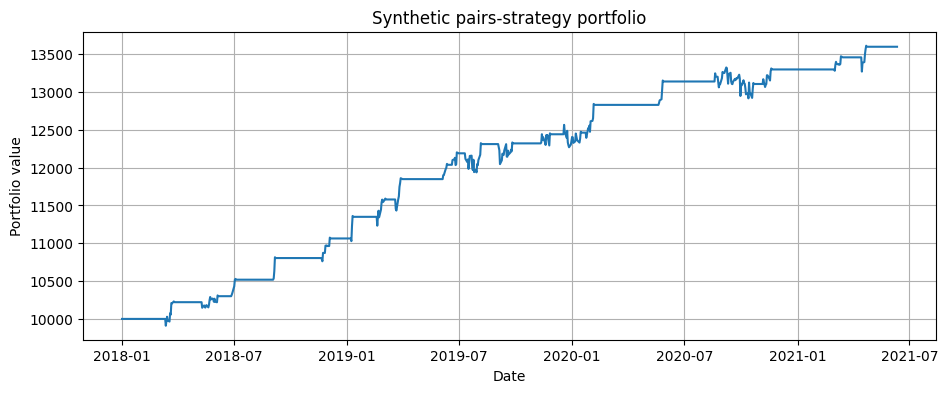

In [18]:
if project_available:
    plt.figure(figsize=(11, 4))
    plt.plot(results.index, results["portfolio"])
    plt.title("Synthetic pairs-strategy portfolio")
    plt.xlabel("Date")
    plt.ylabel("Portfolio value")
    plt.grid(True)
    plt.show()
else:
    print("Skipped.")

# Revision

---

# 92. Complete code-to-theory map

| Code | Theory |
|---|---|
| `np.log(prices).diff()` | Log returns |
| `corr()` | Pearson return correlation |
| `LinearRegression().fit()` | OLS hedge-ratio estimation |
| `y - alpha - beta*x` | Regression residual spread |
| `coint(y, x)` | Engle–Granger cointegration test |
| `adfuller(spread)` | Unit-root test on spread |
| `-log(2)/speed` | Mean-reversion half-life |
| `rolling().mean()` | Local spread equilibrium |
| `rolling().std(ddof=0)` | Rolling spread dispersion |
| `(spread-mean)/std` | Z-score |
| Stateful loop | Entry/exit/stop/time rules |
| `target.shift(1)` | Look-ahead prevention |
| `position/(1+abs(beta))` | Gross-normalized Y weight |
| `-position*beta/(1+abs(beta))` | Hedge-ratio X weight |
| `w_y*r_y + w_x*r_x` | Two-leg gross return |
| `abs(weight-weight.shift())` | Leg turnover |
| `turnover*cost_rate` | Trading cost |
| `short_notional*daily_borrow` | Short-borrow cost |
| `(1+returns).cumprod()` | Compounding |
| `portfolio/portfolio.cummax()-1` | Drawdown |
| Training split | Model development |
| Testing split | Out-of-sample evidence |
| Grid search | Parameter optimization |
| Alpaca current positions | Reconciliation |
| `target-current` | Delta order quantity |

# 93. Formula sheet

## Simple return

$$
r_t=\frac{P_t}{P_{t-1}}-1
$$

## Log return

$$
g_t=\ln(P_t)-\ln(P_{t-1})
$$

## Correlation

$$
\rho_{XY}=
\frac{Cov(X,Y)}
{\sigma_X\sigma_Y}
$$

## Regression relationship

$$
Y_t=\alpha+\beta X_t+\varepsilon_t
$$

## Spread

$$
S_t=Y_t-\alpha-\beta X_t
$$

## Z-score

$$
z_t=\frac{S_t-\mu_t}{\sigma_t}
$$

## Half-life

$$
h=-\frac{\ln 2}{b}
$$

## Y leg weight

$$
w_Y=\frac{p}{1+|\beta|}
$$

## X leg weight

$$
w_X=\frac{-p\beta}{1+|\beta|}
$$

## Gross pair return

$$
r_{pair}=w_Yr_Y+w_Xr_X
$$

## Turnover

$$
TO=|\Delta w_Y|+|\Delta w_X|
$$

## Transaction cost

$$
C=TO\times c
$$

## Borrow cost

$$
B=ShortNotional\times b_d
$$

## Net return

$$
r_{net}=r_{pair}+r_{cash}-C-B
$$

## Portfolio value

$$
V_t=V_0\prod_{i=1}^{t}(1+r_{net,i})
$$

## Sharpe ratio

$$
Sharpe=
\frac{\overline{r-r_f}}{\sigma(r)}\sqrt{252}
$$

## Drawdown

$$
DD_t=
\frac{V_t}{\max(V_1,\ldots,V_t)}-1
$$

# 94. Glossary

| Term | Meaning |
|---|---|
| ADF | Augmented Dickey–Fuller unit-root test |
| Alpha | Regression intercept |
| Beta | Regression hedge ratio |
| Cointegration | Stationary linear combination of non-stationary series |
| Correlation | Linear co-movement measure |
| Dollar neutral | Long and short dollar amounts offset |
| Engle–Granger | Residual-based cointegration procedure |
| Gross exposure | Sum of absolute leg weights |
| Half-life | Estimated time for a deviation to decay by half |
| Hedge ratio | Relative quantity or weight linking the two legs |
| Leg risk | Risk that one order fills before the other |
| Long spread | Long Y and short beta-adjusted X |
| Mean reversion | Tendency to move back toward an equilibrium |
| Net exposure | Sum of signed weights |
| OLS | Ordinary least squares |
| Out of sample | Data not used for model selection |
| Pair trade | Coordinated long and short positions |
| Paper trading | Simulated brokerage execution |
| P-value | Test statistic probability under a null model |
| Residual | Regression error used as spread |
| Short spread | Short Y and long beta-adjusted X |
| Stationary | Stable probabilistic properties over time |
| Statistical arbitrage | Rule-based relative-value trading using statistical evidence |
| Structural break | Change in the underlying relationship |
| Turnover | Magnitude of position-weight change |
| Whipsaw | Repeated losing switches in noisy conditions |
| Z-score | Standardized distance from rolling mean |

# 95. Revision questions

1. What makes pairs trading relative-value rather than purely directional?
2. Why does the project use adjusted prices?
3. Why must both legs be aligned by date?
4. What does return correlation measure?
5. Why is high correlation insufficient?
6. What is beta in the pair regression?
7. What is the residual spread?
8. Why can high R-squared be misleading?
9. What is the cointegration-test null hypothesis?
10. What is the ADF-test null hypothesis?
11. What does stationarity mean in this context?
12. How is half-life estimated?
13. What does a z-score of -2 mean?
14. What is a long-spread trade?
15. What is a short-spread trade?
16. Why is the signal stateful?
17. What is hysteresis?
18. Why use a maximum holding period?
19. Why is a stop needed in mean reversion?
20. What does the execution delay prevent?
21. Why do absolute leg weights sum to one?
22. Is the strategy always dollar neutral?
23. How is pair return calculated?
24. Why are costs charged on both legs?
25. What additional cost applies to the short leg?
26. Why can paper and live fills differ?
27. What is market exposure?
28. What is the difference between a rebalance day and a completed trade?
29. What does profit factor above one mean?
30. Why is the passive benchmark imperfect but useful?
31. Why must pair selection use training data only?
32. What is indicator warm-up?
33. Does the test carry an open training trade?
34. Why does grid search increase false-discovery risk?
35. What is a structural break?
36. Why is a small p-value not a guarantee?
37. Why is a dry run the default for Alpaca?
38. What is leg risk?
39. Why does integer-share rounding matter?
40. Name five missing production features.

# 96. Answers

1. It takes opposing positions and targets the relationship rather than one market direction.
2. To reduce artificial jumps from corporate actions according to the provider.
3. Regression and returns must compare the same trading dates.
4. Linear co-movement of short-term returns.
5. A price relationship can drift permanently despite correlated changes.
6. The estimated hedge ratio linking X to Y.
7. Y minus the fitted alpha and beta-adjusted X.
8. Trending unrelated series can produce spurious regression.
9. The series are not cointegrated.
10. The spread has a unit root and is non-stationary.
11. Its distributional properties are approximately stable through time.
12. Regress spread change on lagged spread and use `-ln(2)/b`.
13. The spread is two rolling standard deviations below its rolling mean.
14. Long Y and short beta-adjusted X.
15. Short Y and long beta-adjusted X.
16. Action depends on whether the strategy is flat, long spread, or short spread.
17. Different entry and exit boundaries that reduce rapid switching.
18. To limit stale trades and capital lock-up.
19. Divergence can be a broken relationship rather than temporary mispricing.
20. Same-period future-information leakage.
21. The project normalizes total gross exposure to one.
22. No; net exposure is zero only under particular beta values.
23. Weighted return of Y plus weighted return of X.
24. Both stocks must be traded.
25. Borrow cost, plus operational short risks not fully modelled.
26. Paper systems do not reproduce real queueing, spread, impact, borrow, or latency.
27. Fraction of observations with an active spread position.
28. Rebalancing counts execution activity; a trade spans entry to exit.
29. Winning-return magnitude exceeds losing-return magnitude.
30. It shows whether complexity beats simply owning both stocks.
31. Otherwise testing information leaks into the model.
32. Earlier observations used to calculate rolling indicators.
33. No; the testing backtest starts fresh from cash.
34. Some combinations appear strong by chance.
35. A change in the underlying economic or statistical relationship.
36. It is conditional evidence under assumptions, not a future probability.
37. To prevent accidental order submission.
38. One leg fills before the other.
39. Actual weights differ from the theoretical hedge.
40. Examples: atomic execution, fill monitoring, dynamic borrow, market impact, margin controls, kill switches, and multi-pair risk allocation.

<div style="padding:20px 24px;border:1px solid #d0d7de;border-radius:12px;">
<h2 style="margin-top:0;">Final mental model</h2>

The project has three linked chains:

```text
Selection:
Universe → Correlation → Regression → Cointegration → ADF → Half-life
```

```text
Trading:
Spread → Z-score → Stateful signal → Delayed pair weights → Two-leg P&L
```

```text
Research:
Training selection → Frozen model → Out-of-sample evaluation → Paper execution
```

Every chain can fail. Good code does not guarantee a stable relationship, and strong historical statistics do not guarantee executable profits.
</div>